In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
import os
from pathlib import Path

mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

print("✅ All libraries imported successfully")
print(f"   OpenCV    : {cv2.__version__}")
print(f"   MediaPipe : {mp.__version__}")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")


✅ All libraries imported successfully
   OpenCV    : 4.13.0
   MediaPipe : 0.10.13
   NumPy     : 2.4.3
   Pandas    : 3.0.1


In [3]:
# ─────────────────────────────────────────
# CELL 2: Load Dataset & CSV
# ─────────────────────────────────────────

# Define paths
DATASET_ROOT = Path("ARAN")
CSV_PATH     = DATASET_ROOT / "labels.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

# Rename columns for easier use
df.columns = ['child_id', 'gender', 'height_cm', 
              'weight_g', 'head_circ_cm', 
              'waist_cm', 'age_months']

# Basic info
print(f"✅ CSV loaded successfully")
print(f"   Total children : {len(df)}")
print(f"   Columns        : {list(df.columns)}")
print(f"\n📋 First 5 rows:")
print(df.head())
print(f"\n📊 Basic Stats:")
print(df.describe())


✅ CSV loaded successfully
   Total children : 512
   Columns        : ['child_id', 'gender', 'height_cm', 'weight_g', 'head_circ_cm', 'waist_cm', 'age_months']

📋 First 5 rows:
    child_id gender  height_cm  weight_g  head_circ_cm  waist_cm  age_months
0  child0001      f      100.0     15000          51.0        53          42
1  child0002      f      118.0     28400          52.5        66          78
2  child0003      m       95.7     19000          50.0        52          33
3  child0004      m      109.5     21400          52.0        62          53
4  child0005      m       93.5     12100          50.0        49          36

📊 Basic Stats:
        height_cm      weight_g  head_circ_cm    waist_cm  age_months
count  512.000000    512.000000     512.00000  512.000000  512.000000
mean   110.993164  18983.203125      50.19043   53.416016   65.431641
std     12.197511   5184.274647       2.46112    5.371227   20.223488
min     73.000000   9300.000000      37.50000   36.000000   16.00

In [4]:
# ─────────────────────────────────────────
# CELL 3: Load All Image Paths
# ─────────────────────────────────────────

image_records = []

# Loop through female and Male folders
for gender_folder in ['female', 'Male']:
    gender_path = DATASET_ROOT / gender_folder
    
    if not gender_path.exists():
        print(f"⚠️ Folder not found: {gender_path}")
        continue
    
    # Loop through each child folder
    for child_folder in sorted(gender_path.iterdir()):
        if not child_folder.is_dir():
            continue
        
        child_id = child_folder.name  # e.g. child0103
        
        # Get all 4 images for this child
        images = sorted(child_folder.glob("*.jpg"))
        
        for img_path in images:
            image_records.append({
                'child_id'  : child_id,
                'gender'    : 'f' if gender_folder == 'female' else 'm',
                'img_path'  : str(img_path),
                'img_name'  : img_path.name
            })

# Convert to dataframe
img_df = pd.DataFrame(image_records)

print(f"✅ Images loaded successfully")
print(f"   Total images     : {len(img_df)}")
print(f"   Total children   : {img_df['child_id'].nunique()}")
print(f"   Images per child : {len(img_df) // img_df['child_id'].nunique()}")
print(f"\n📋 Sample image records:")
print(img_df.head(8))


✅ Images loaded successfully
   Total images     : 1641
   Total children   : 410
   Images per child : 4

📋 Sample image records:
    child_id gender                                img_path          img_name
0  child0103      f  ARAN\female\child0103\child0103_01.jpg  child0103_01.jpg
1  child0103      f  ARAN\female\child0103\child0103_02.jpg  child0103_02.jpg
2  child0103      f  ARAN\female\child0103\child0103_03.jpg  child0103_03.jpg
3  child0103      f  ARAN\female\child0103\child0103_04.jpg  child0103_04.jpg
4  child0104      f  ARAN\female\child0104\child0104_01.jpg  child0104_01.jpg
5  child0104      f  ARAN\female\child0104\child0104_02.jpg  child0104_02.jpg
6  child0104      f  ARAN\female\child0104\child0104_03.jpg  child0104_03.jpg
7  child0104      f  ARAN\female\child0104\child0104_04.jpg  child0104_04.jpg


In [5]:
# ─────────────────────────────────────────
# CELL 4: Quality Check Functions
# Stage 1 - The 3 Checks
# ─────────────────────────────────────────

# Thresholds
BLUR_THRESHOLD     = 100.0   # Laplacian variance - below this = blurry
BRIGHTNESS_MIN     = 40.0    # Too dark
BRIGHTNESS_MAX     = 220.0   # Too bright

# Initialize MediaPipe Pose once (reuse for all images)
pose_detector = mp_pose.Pose(
    static_image_mode       = True,   # True for static images (not video)
    min_detection_confidence = 0.4,   # Slightly lower for dataset images
    min_tracking_confidence  = 0.4
)

# ── CHECK 1: BLUR ──────────────────────────────────────
def check_blur(img):
    gray          = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    passed        = laplacian_var >= BLUR_THRESHOLD
    return {
        "passed"  : passed,
        "score"   : round(laplacian_var, 2),
        "message" : "Sharp" if passed else "Too Blurry"
    }

# ── CHECK 2: BRIGHTNESS ────────────────────────────────
def check_brightness(img):
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = round(float(np.mean(gray)), 2)
    
    if brightness < BRIGHTNESS_MIN:
        return {"passed": False, "score": brightness, "message": "Too Dark"}
    elif brightness > BRIGHTNESS_MAX:
        return {"passed": False, "score": brightness, "message": "Too Bright"}
    else:
        return {"passed": True,  "score": brightness, "message": "Good Lighting"}

# ── CHECK 3: PERSON IN FRAME ───────────────────────────
def check_framing(img):
    rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = pose_detector.process(rgb)
    
    if not results.pose_landmarks:
        return {
            "passed"    : False,
            "visibility": 0.0,
            "message"   : "No Person Detected"
        }
    
    # Check visibility of 4 key landmarks
    lm = results.pose_landmarks.landmark
    key_points = [
        mp_pose.PoseLandmark.LEFT_SHOULDER,
        mp_pose.PoseLandmark.RIGHT_SHOULDER,
        mp_pose.PoseLandmark.LEFT_HIP,
        mp_pose.PoseLandmark.RIGHT_HIP
    ]
    avg_vis = float(np.mean([lm[k.value].visibility for k in key_points]))
    passed  = avg_vis >= 0.5
    
    return {
        "passed"    : passed,
        "visibility": round(avg_vis, 3),
        "message"   : "Person Detected" if passed else "Body Not Fully Visible"
    }

# ── RUN ALL 3 CHECKS ───────────────────────────────────
def run_quality_checks(img_path):
    img = cv2.imread(img_path)
    
    if img is None:
        return None
    
    blur       = check_blur(img)
    brightness = check_brightness(img)
    framing    = check_framing(img)
    all_passed = blur["passed"] and brightness["passed"] and framing["passed"]
    
    return {
        "all_passed" : all_passed,
        "blur"       : blur,
        "brightness" : brightness,
        "framing"    : framing
    }

print("✅ Quality check functions defined successfully")
print(f"   Blur threshold     : {BLUR_THRESHOLD}")
print(f"   Brightness range   : {BRIGHTNESS_MIN} - {BRIGHTNESS_MAX}")
print(f"   MediaPipe Pose     : Initialized")
print(f"\n   3 checks ready:")
print(f"   1. check_blur()       → Laplacian variance")
print(f"   2. check_brightness() → Mean pixel intensity")
print(f"   3. check_framing()    → MediaPipe pose detection")


✅ Quality check functions defined successfully
   Blur threshold     : 100.0
   Brightness range   : 40.0 - 220.0
   MediaPipe Pose     : Initialized

   3 checks ready:
   1. check_blur()       → Laplacian variance
   2. check_brightness() → Mean pixel intensity
   3. check_framing()    → MediaPipe pose detection


In [6]:
# ─────────────────────────────────────────
# CELL 5: Test Quality Checks on 5 Samples
# ─────────────────────────────────────────

# Pick 5 random images to test
sample_images = img_df.sample(5, random_state=42)

print("🔍 Testing quality checks on 5 sample images...\n")
print(f"{'Image':<25} {'Blur':>8} {'Bright':>8} {'Visibility':>12} {'Result':>10}")
print("-" * 70)

for _, row in sample_images.iterrows():
    result = run_quality_checks(row['img_path'])
    
    if result is None:
        print(f"{row['img_name']:<25} {'ERROR - Could not load image':>40}")
        continue
    
    status = "✅ PASS" if result['all_passed'] else "❌ FAIL"
    
    print(f"{row['img_name']:<25}"
          f"{result['blur']['score']:>8.1f}"
          f"{result['brightness']['score']:>8.1f}"
          f"{result['framing']['visibility']:>12.3f}"
          f"   {status}")
    
    # Show individual check messages if failed
    if not result['all_passed']:
        if not result['blur']['passed']:
            print(f"   ↳ Blur     : {result['blur']['message']}")
        if not result['brightness']['passed']:
            print(f"   ↳ Bright   : {result['brightness']['message']}")
        if not result['framing']['passed']:
            print(f"   ↳ Framing  : {result['framing']['message']}")

print("-" * 70)
print("\n✅ Sample test complete — ready to run on full dataset")


🔍 Testing quality checks on 5 sample images...

Image                         Blur   Bright   Visibility     Result
----------------------------------------------------------------------


c:\Users\cpans\OneDrive\Desktop\Nutrivision\nutrivision_env\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


child0431_02.jpg             80.1   155.1       0.997   ❌ FAIL
   ↳ Blur     : Too Blurry
child0361_04.jpg            238.0   156.1       0.998   ✅ PASS
child0172_01.jpg             79.3   151.9       1.000   ❌ FAIL
   ↳ Blur     : Too Blurry
child0394_04.jpg            102.2   146.4       0.998   ✅ PASS
child0390_02.jpg            265.8   192.7       0.996   ✅ PASS
----------------------------------------------------------------------

✅ Sample test complete — ready to run on full dataset


In [7]:
# ─────────────────────────────────────────
# CELL 6: Run Quality Checks on ALL Images
# ─────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')  # Suppress MediaPipe warnings

results_list = []
total        = len(img_df)

print(f"🔍 Running quality checks on all {total} images...")
print(f"   This will take 2-3 minutes, please wait...\n")

for i, row in img_df.iterrows():
    result = run_quality_checks(row['img_path'])
    
    if result is None:
        continue
    
    results_list.append({
        'child_id'          : row['child_id'],
        'gender'            : row['gender'],
        'img_name'          : row['img_name'],
        'img_path'          : row['img_path'],
        'all_passed'        : result['all_passed'],
        'blur_score'        : result['blur']['score'],
        'blur_passed'       : result['blur']['passed'],
        'blur_message'      : result['blur']['message'],
        'brightness_score'  : result['brightness']['score'],
        'brightness_passed' : result['brightness']['passed'],
        'brightness_message': result['brightness']['message'],
        'visibility_score'  : result['framing']['visibility'],
        'framing_passed'    : result['framing']['passed'],
        'framing_message'   : result['framing']['message'],
    })
    
    # Progress update every 200 images
    count = len(results_list)
    if count % 200 == 0:
        print(f"   ✓ Processed {count}/{total} images...")

# Convert to dataframe
results_df = pd.DataFrame(results_list)

# Summary
passed = results_df['all_passed'].sum()
failed = len(results_df) - passed

print(f"\n{'='*45}")
print(f"✅ ALL CHECKS COMPLETE")
print(f"{'='*45}")
print(f"   Total images processed : {len(results_df)}")
print(f"   PASSED all 3 checks    : {passed} ({passed/len(results_df)*100:.1f}%)")
print(f"   FAILED at least 1      : {failed} ({failed/len(results_df)*100:.1f}%)")
print(f"\n   Individual check stats:")
print(f"   Blur passed      : {results_df['blur_passed'].sum()} ({results_df['blur_passed'].mean()*100:.1f}%)")
print(f"   Brightness passed: {results_df['brightness_passed'].sum()} ({results_df['brightness_passed'].mean()*100:.1f}%)")
print(f"   Framing passed   : {results_df['framing_passed'].sum()} ({results_df['framing_passed'].mean()*100:.1f}%)")


🔍 Running quality checks on all 1641 images...
   This will take 2-3 minutes, please wait...

   ✓ Processed 200/1641 images...
   ✓ Processed 400/1641 images...
   ✓ Processed 600/1641 images...
   ✓ Processed 800/1641 images...
   ✓ Processed 1000/1641 images...
   ✓ Processed 1200/1641 images...
   ✓ Processed 1400/1641 images...
   ✓ Processed 1600/1641 images...

✅ ALL CHECKS COMPLETE
   Total images processed : 1641
   PASSED all 3 checks    : 1017 (62.0%)
   FAILED at least 1      : 624 (38.0%)

   Individual check stats:
   Blur passed      : 1027 (62.6%)
   Brightness passed: 1641 (100.0%)
   Framing passed   : 1627 (99.1%)


📊 Blur Score Distribution:
   Min    : 10.9
   Max    : 1945.6
   Mean   : 248.4
   Median : 135.9

   Images passing at different thresholds:
    Threshold   Pass Count     Pass %
   -----------------------------------
           30         1566      95.4%
           40         1471      89.6%
           50         1373      83.7%
           60         1289      78.5%
           70         1224      74.6%
           80         1161      70.7%
          100         1027      62.6% ← current


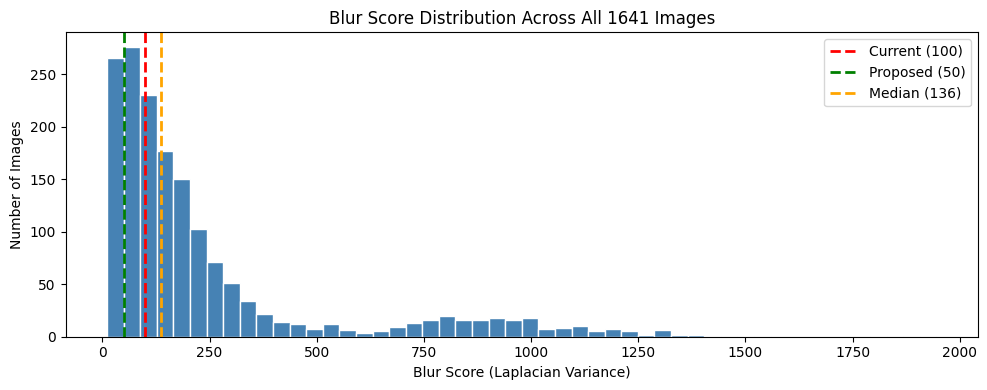


💡 Recommendation: Look at the table above
   Choose threshold where 80-85% of images pass


In [8]:
# ─────────────────────────────────────────
# CELL 7: Analyze Blur Score Distribution
# Find the right threshold
# ─────────────────────────────────────────

blur_scores = results_df['blur_score']

print("📊 Blur Score Distribution:")
print(f"   Min    : {blur_scores.min():.1f}")
print(f"   Max    : {blur_scores.max():.1f}")
print(f"   Mean   : {blur_scores.mean():.1f}")
print(f"   Median : {blur_scores.median():.1f}")
print(f"\n   Images passing at different thresholds:")
print(f"   {'Threshold':>10} {'Pass Count':>12} {'Pass %':>10}")
print(f"   {'-'*35}")

for thresh in [30, 40, 50, 60, 70, 80, 100]:
    count   = (blur_scores >= thresh).sum()
    percent = count / len(blur_scores) * 100
    marker  = " ← current" if thresh == 100 else ""
    print(f"   {thresh:>10} {count:>12} {percent:>9.1f}%{marker}")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(blur_scores, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=100, color='red',    linestyle='--', linewidth=2, label='Current (100)')
plt.axvline(x=50,  color='green',  linestyle='--', linewidth=2, label='Proposed (50)')
plt.axvline(x=blur_scores.median(), 
                   color='orange', linestyle='--', linewidth=2, 
                   label=f'Median ({blur_scores.median():.0f})')
plt.xlabel('Blur Score (Laplacian Variance)')
plt.ylabel('Number of Images')
plt.title('Blur Score Distribution Across All 1641 Images')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Recommendation: Look at the table above")
print("   Choose threshold where 80-85% of images pass")


  STAGE 1 - FINAL QUALITY CHECK RESULTS

  Thresholds Used:
  Blur       : >= 50.0 (Laplacian variance)
  Brightness : 40.0 - 220.0 (mean intensity)
  Framing    : >= 0.5 visibility (MediaPipe)

  Dataset: ARAN
  Total images processed : 1641
  Total children         : 410

  ✅ PASSED all 3 checks : 1362 (83.0%)
  ❌ FAILED at least 1   : 279 (17.0%)

  Individual Check Results:
  Blur       passed : 1373 (83.7%)
  Brightness passed : 1641 (100.0%)
  Framing    passed : 1627 (99.1%)

  Failure Breakdown:
  Failed blur only    : 265
  Failed framing only : 11
  Failed multiple     : 3


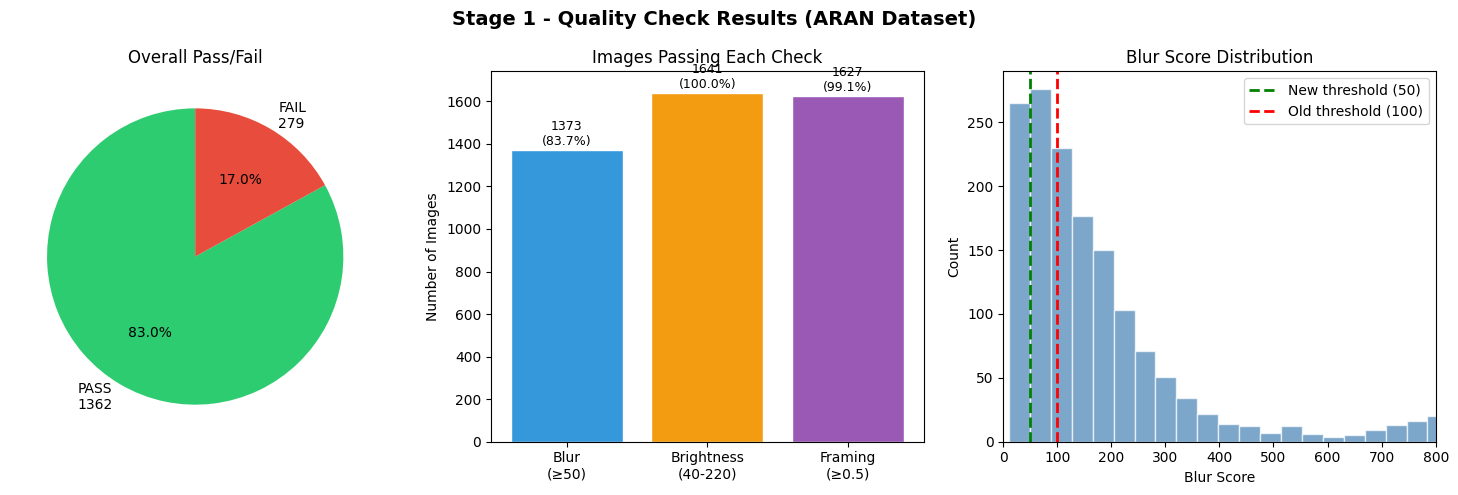


✅ Stage 1 Implementation Complete!
   1362 images accepted → ready for Stage 2 preprocessing


In [9]:
# ─────────────────────────────────────────
# CELL 8: Final Results with Tuned Threshold
# Blur threshold updated: 100 → 50
# ─────────────────────────────────────────

# Update threshold
BLUR_THRESHOLD = 50.0

# Recalculate pass/fail on existing results
# (No need to re-run MediaPipe, just recalculate blur column)
results_df['blur_passed']  = results_df['blur_score'] >= BLUR_THRESHOLD
results_df['all_passed']   = (
    results_df['blur_passed'] &
    results_df['brightness_passed'] &
    results_df['framing_passed']
)

passed = results_df['all_passed'].sum()
failed = len(results_df) - passed

print("=" * 50)
print("  STAGE 1 - FINAL QUALITY CHECK RESULTS")
print("=" * 50)
print(f"\n  Thresholds Used:")
print(f"  Blur       : >= {BLUR_THRESHOLD} (Laplacian variance)")
print(f"  Brightness : {BRIGHTNESS_MIN} - {BRIGHTNESS_MAX} (mean intensity)")
print(f"  Framing    : >= 0.5 visibility (MediaPipe)")

print(f"\n  Dataset: ARAN")
print(f"  Total images processed : {len(results_df)}")
print(f"  Total children         : {results_df['child_id'].nunique()}")

print(f"\n  ✅ PASSED all 3 checks : {passed} ({passed/len(results_df)*100:.1f}%)")
print(f"  ❌ FAILED at least 1   : {failed} ({failed/len(results_df)*100:.1f}%)")

print(f"\n  Individual Check Results:")
print(f"  Blur       passed : {results_df['blur_passed'].sum()} ({results_df['blur_passed'].mean()*100:.1f}%)")
print(f"  Brightness passed : {results_df['brightness_passed'].sum()} ({results_df['brightness_passed'].mean()*100:.1f}%)")
print(f"  Framing    passed : {results_df['framing_passed'].sum()} ({results_df['framing_passed'].mean()*100:.1f}%)")

print(f"\n  Failure Breakdown:")
blur_only   = (~results_df['blur_passed'] & results_df['brightness_passed'] & results_df['framing_passed']).sum()
frame_only  = (results_df['blur_passed'] & results_df['brightness_passed'] & ~results_df['framing_passed']).sum()
multi_fail  = failed - blur_only - frame_only
print(f"  Failed blur only    : {blur_only}")
print(f"  Failed framing only : {frame_only}")
print(f"  Failed multiple     : {multi_fail}")

# ── VISUALIZATION ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Stage 1 - Quality Check Results (ARAN Dataset)', 
             fontsize=14, fontweight='bold')

# Chart 1: Overall Pass/Fail
axes[0].pie([passed, failed],
            labels=[f'PASS\n{passed}', f'FAIL\n{failed}'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[0].set_title('Overall Pass/Fail')

# Chart 2: Individual Check Pass Rates
checks      = ['Blur\n(≥50)', 'Brightness\n(40-220)', 'Framing\n(≥0.5)']
pass_counts = [
    results_df['blur_passed'].sum(),
    results_df['brightness_passed'].sum(),
    results_df['framing_passed'].sum()
]
colors = ['#3498db', '#f39c12', '#9b59b6']
bars   = axes[1].bar(checks, pass_counts, color=colors, edgecolor='white')
axes[1].set_ylim(0, len(results_df) + 100)
axes[1].set_title('Images Passing Each Check')
axes[1].set_ylabel('Number of Images')
for bar, count in zip(bars, pass_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{count}\n({count/len(results_df)*100:.1f}%)',
                 ha='center', fontsize=9)

# Chart 3: Blur score distribution with new threshold
axes[2].hist(results_df['blur_score'], bins=50, 
             color='steelblue', edgecolor='white', alpha=0.7)
axes[2].axvline(x=50,  color='green', linestyle='--', 
                linewidth=2, label='New threshold (50)')
axes[2].axvline(x=100, color='red',   linestyle='--', 
                linewidth=2, label='Old threshold (100)')
axes[2].set_title('Blur Score Distribution')
axes[2].set_xlabel('Blur Score')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].set_xlim(0, 800)

plt.tight_layout()
plt.show()

print("\n✅ Stage 1 Implementation Complete!")
print(f"   {passed} images accepted → ready for Stage 2 preprocessing")
